Создайте автокодировщик, удаляющий черные квадраты в случайных областях изображений.

Алгоритм действий:
1. Возьмите базу картинок MNIST.
2. На картинках в случайных местах сделайте чёрные квадраты размера 8 на 8.
3. Создайте и обучите автокодировщик восстанавливать оригинальные изображения из повреждённых изображений.
4. Добейтесь MSE < 0.0070 на тестовой выборке.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

%matplotlib inline


In [2]:
# Функция загружает MNIST, нормирует пиксели и добавляет размерность канала.
def load_mnist_images():
    (train_images, _), (test_images, _) = mnist.load_data()

    train_images = train_images.astype("float32") / 255.0
    test_images = test_images.astype("float32") / 255.0

    train_images = train_images[..., np.newaxis]
    test_images = test_images[..., np.newaxis]

    return train_images, test_images


X_train_org, X_test_org = load_mnist_images()

print("Размер обучающей выборки:", X_train_org.shape)
print("Размер тестовой выборки:", X_test_org.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Размер обучающей выборки: (60000, 28, 28, 1)
Размер тестовой выборки: (10000, 28, 28, 1)


In [3]:
# Функция создаёт копию изображений и закрывает случайную область чёрным квадратом.
def make_masked_copy(images, square_side=8, seed=42):
    rng = np.random.default_rng(seed)
    result = images.copy()

    count, img_height, img_width, _ = result.shape
    max_y = img_height - square_side + 1
    max_x = img_width - square_side + 1

    for image_id in range(count):
        y0 = rng.integers(0, max_y)
        x0 = rng.integers(0, max_x)
        result[image_id, y0:y0 + square_side, x0:x0 + square_side, 0] = 0.0

    return result


X_train_masked = make_masked_copy(X_train_org, square_side=8, seed=42)
X_test_masked = make_masked_copy(X_test_org, square_side=8, seed=84)

print("Оригинальные изображения:", X_train_org.shape)
print("Повреждённые изображения:", X_train_masked.shape)


Оригинальные изображения: (60000, 28, 28, 1)
Повреждённые изображения: (60000, 28, 28, 1)


In [4]:
# Функция собирает сверточный автокодировщик для восстановления закрытых областей.
def build_inpainting_autoencoder(input_shape=(28, 28, 1), learning_rate=0.001):
    image_input = Input(shape=input_shape, name="masked_image")

    # Энкодер сжимает изображение и выделяет признаки.
    z = Conv2D(32, kernel_size=3, padding="same", activation="relu")(image_input)
    z = BatchNormalization()(z)

    z = Conv2D(64, kernel_size=3, strides=2, padding="same", activation="relu")(z)
    z = BatchNormalization()(z)

    z = Conv2D(128, kernel_size=3, strides=2, padding="same", activation="relu")(z)
    z = BatchNormalization()(z)

    # Декодер возвращает карту признаков к размеру исходного изображения.
    z = Conv2DTranspose(128, kernel_size=3, strides=2, padding="same", activation="relu")(z)
    z = BatchNormalization()(z)

    z = Conv2DTranspose(64, kernel_size=3, strides=2, padding="same", activation="relu")(z)
    z = BatchNormalization()(z)

    restored_image = Conv2D(1, kernel_size=3, padding="same", activation="sigmoid", name="restored_image")(z)

    model = Model(image_input, restored_image, name="mnist_square_restorer")
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")

    return model


autoencoder = build_inpainting_autoencoder()
autoencoder.summary()


Model: "mnist_square_restorer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masked_image (InputLayer)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ restored_image (Conv2D)         │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,289 (1.21 MB)

 Trainable params: 315,457 (1.20 MB)

 Non-trainable params: 832 (3.25 KB)

In [5]:
# Обучение идёт по схеме: на вход подаются изображения с квадратом, а целевой ответ — чистые изображения.
def train_model(model, x_train, y_train, x_valid, y_valid, epochs=10, batch_size=128):
    return model.fit(
        x_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        shuffle=True,
        validation_data=(x_valid, y_valid),
        verbose=1
    )


history = train_model(
    autoencoder,
    X_train_masked,
    X_train_org,
    X_test_masked,
    X_test_org,
    epochs=10,
    batch_size=128
)

test_mse = history.history["val_loss"][-1]

print(f"Итоговая ошибка MSE на тестовой выборке: {test_mse:.5f}")

if test_mse < 0.0070:
    print("Условие задания выполнено: MSE меньше 0.0070.")
else:
    print("Условие задания не выполнено: MSE не меньше 0.0070.")


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0139 - val_loss: 0.0471
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0058 - val_loss: 0.0138
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0049 - val_loss: 0.0052
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.0045 - val_loss: 0.0200
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0042 - val_loss: 0.0047
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0040 - val_loss: 0.0105
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.0038 - val_loss: 0.0043
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0037 - val_loss: 0.0048
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.0036 - val_loss: 0.0235
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.0035 - val_loss: 0.0039
Итоговая ошибка MSE на тестовой выборке: 0.00389
Условие задания выполнено: MSE меньше 0.0070.


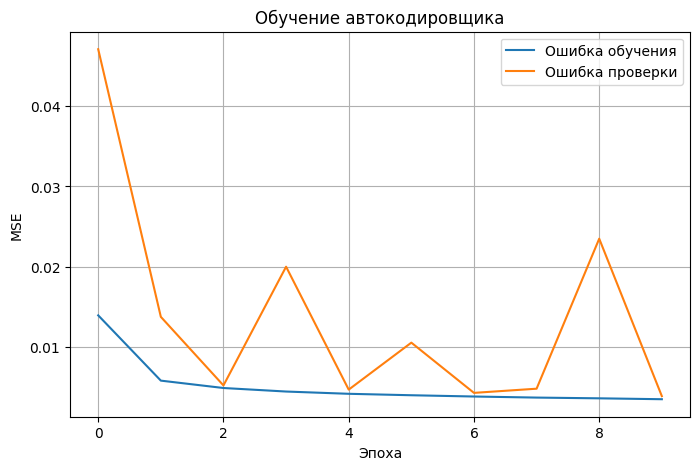

In [6]:
# График показывает, как менялась ошибка на обучающей и тестовой выборках.
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Ошибка обучения")
plt.plot(history.history["val_loss"], label="Ошибка проверки")
plt.xlabel("Эпоха")
plt.ylabel("MSE")
plt.title("Обучение автокодировщика")
plt.legend()
plt.grid(True)
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


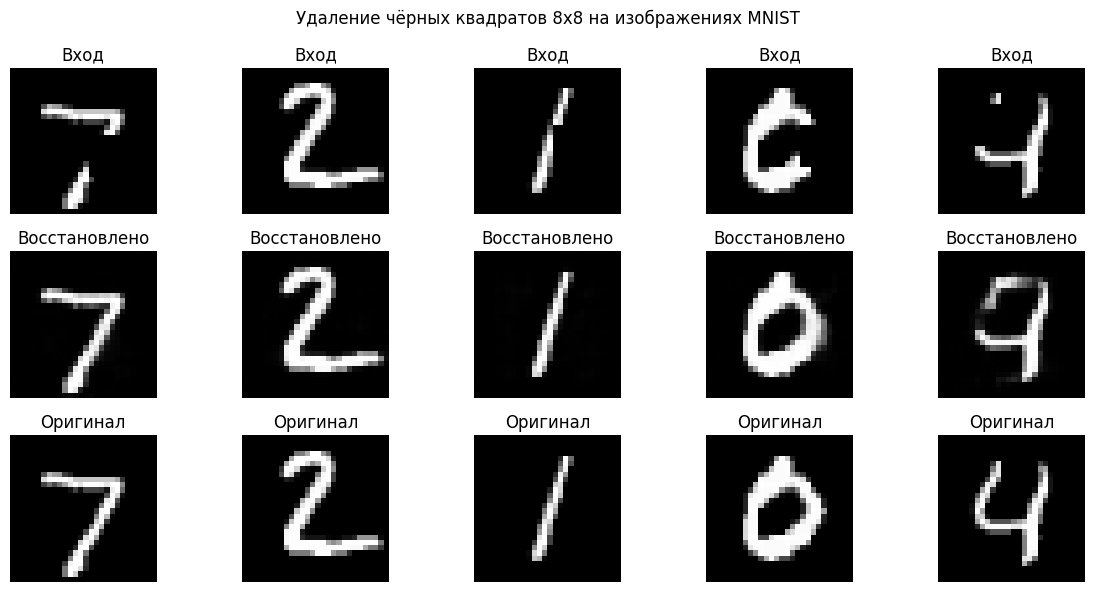

In [7]:
# Получаем восстановленные изображения и сравниваем их с входом и оригиналом.
restored_test_images = autoencoder.predict(X_test_masked)

show_count = 5
plt.figure(figsize=(12, 6))

for idx in range(show_count):
    plt.subplot(3, show_count, idx + 1)
    plt.imshow(X_test_masked[idx].reshape(28, 28), cmap="gray")
    plt.title("Вход")
    plt.axis("off")

    plt.subplot(3, show_count, idx + 1 + show_count)
    plt.imshow(restored_test_images[idx].reshape(28, 28), cmap="gray")
    plt.title("Восстановлено")
    plt.axis("off")

    plt.subplot(3, show_count, idx + 1 + 2 * show_count)
    plt.imshow(X_test_org[idx].reshape(28, 28), cmap="gray")
    plt.title("Оригинал")
    plt.axis("off")

plt.suptitle("Удаление чёрных квадратов 8x8 на изображениях MNIST")
plt.tight_layout()
plt.show()
